# P2

## Importar bibliotecas

In [22]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
import scipy.stats as stats
import numpy as np

#### Definir style sheet

In [2]:
# 1. Apply base seaborn-paper style
plt.style.use('seaborn-v0_8-paper')  # Use 'seaborn-paper' if on older matplotlib versions

# 2. Overhaul rcParams for maximum article readability
plt.rcParams.update({
    # Text and Typography
    "text.usetex": False,                   # Set to True ONLY if you have a local LaTeX installation
    
    # Font Sizes (Optimized for standard paper columns)
    "axes.labelsize": 10,                   # X and Y axis titles
    "axes.titlesize": 11,                   # Plot title
    "xtick.labelsize": 8,                   # X-axis tick labels
    "ytick.labelsize": 8,                   # Y-axis tick labels
    "legend.fontsize": 8,                   # Legend items font size
    "legend.title_fontsize": 9,             # Legend title font size
    
    # Figure Layout & Dimensions
    "figure.figsize": [3.39, 2.5],          # Fits standard 3.39-inch single columns (e.g., IEEE/Nature)
    "figure.constrained_layout.use": True,  # Auto-adjusts padding to prevent clipped text
    "figure.dpi": 150,                      # Crisp display rendering on high-res monitors
    
    # Plot Styling details
    "axes.spines.top": False,               # Strip away top bounding box border
    "axes.spines.right": False,             # Strip away right bounding box border
    "axes.grid": True,                      # Keep grids enabled for data alignment
    "grid.alpha": 0.3,                      # Make grid lines subtle and unobtrusive
    "grid.linestyle": "--",                 # Dashed grid lines
    "lines.linewidth": 1.25,                # Slightly thicker lines for visibility
    "lines.markersize": 4,                  # Balanced data marker dots
    
    # Vector Graphics Export Stability
    "pdf.fonttype": 42,                     # Embed true fonts inside PDFs (prevents text errors)
    "ps.fonttype": 42                       # Embed true fonts inside PostScript formats
})

pd.set_option('display.max_columns', 50)  # Remove o limite de colunas
pd.set_option('display.max_rows', 100)     # Remove o limite de linhas
pd.set_option('display.width', 300)        # Evita que o texto quebre para a linha de baixo

## EDA e Pré Processamento
### Carregar Dataframe

In [3]:
DATASET_FILE_PATH = "PTD_level_dataset.xlsx"
df = pd.read_excel(DATASET_FILE_PATH)
df.head()


,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,PVE_PTD,D_PTD,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,64.08,3.522977,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,-13.20,3.522977,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,173.10,3.522977,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


| # | Propriedade | Tipo | Descrição |
|---|---|---|---|
| 1 | Distrito | Categórica | Distrito português onde o PTD está localizado |
| 2 | Concelho | Categórica | Concelho associado ao PTD |
| 3 | CodDistritoConcelho | Identificador | Código único que representa a combinação distrito + concelho |
| 4 | Código de Instalação | Identificador | Identificador único do Posto de Transformação |
| 5 | Coordenadas Geográficas | Geográfica | Latitude e longitude do PTD |
| 6 | Potência instalada [kVA] | Numérica | Potência nominal instalada no PTD |
| 7 | Tipo Construtivo | Categórica | Tipo físico/construtivo do PTD |
| 8 | Cap_PTD_kVA | Numérica | Capacidade total do PTD em kVA |
| 9 | Pot_Contratada_kVA | Numérica | Soma da potência contratada pelos clientes ligados ao PTD |
| 10 | N_Clientes | Inteira | Número total de clientes associados ao PTD |
| 11 | Pot_Geracao_kW | Numérica | Potência de geração local (produção elétrica distribuída) |
| 12 | N_Clientes_Produtores | Inteira | Número de clientes produtores de energia |
| 13 | P_IP_Total | Numérica | Potência total consumida pela iluminação pública |
| 14 | P_IP_Inef | Numérica | Potência associada à iluminação pública ineficiente |
| 15 | Rate_Ineficiencia | Numérica | Taxa de ineficiência energética da iluminação pública |
| 16 | LED_Ratio | Numérica | Percentagem/proporção de luminárias LED |
| 17 | N_Luminarias | Inteira | Número total de luminárias |
| 18 | N_Lampadas | Inteira | Número total de lâmpadas |
| 19 | N_PTDs_Concelho | Inteira | Número de PTD existentes no concelho |
| 20 | PVE_PTD | Numérica | Potência estimada necessária para veículos elétricos |
| 21 | D_PTD | Numérica | Saldo de viabilidade energética do PTD |
| 22 | IP_per_PTD | Numérica | Média da potência de iluminação pública por PTD |
| 23 | IP_Inef_per_PTD | Numérica | Média da potência ineficiente por PTD |
| 24 | Ganho_LED_PTD | Numérica | Ganho energético obtido pela substituição por LED |
| 25 | D_PTD_LED | Numérica | Saldo energético do PTD após modernização LED |
| 26 | Cap_per_Cliente | Numérica | Capacidade média disponível por cliente |
| 27 | PContratada_per_Cliente | Numérica | Potência contratada média por cliente |
| 28 | Geracao_per_Cliente | Numérica | Geração média de energia por cliente |
| 29 | Clientes_Produtores_Ratio | Numérica | Percentagem/proporção de clientes produtores |
| 30 | Nível de Utilização [%] | Numérica | Percentagem de utilização da capacidade do PTD |
| 31 | Util_Decimal | Numérica | Representação decimal do nível de utilização |
| 32 | PFolga_PTD | Numérica (Target) | Capacidade livre/remanescente do PTD para novas cargas elétricas |

In [4]:
# Primeira limpeza
df.drop_duplicates(inplace= True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  object 
 1   Concelho                   72027 non-null  object 
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  object 
 4   Coordenadas Geográficas    72027 non-null  object 
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  object 
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  72027 non-null  flo

In [6]:
df["CodDistritoConcelho"] = df["CodDistritoConcelho"].astype(str).astype('category')

### Resumo
- Tamanho: ~72.000 registos; mix de variáveis categóricas, inteiras e decimais.

- Nulos: Pot_Contratada_kVA, Pot_Geracao_kW, D_PTD, D_PTD_LED, Geracao_per_Cliente,Util_Decimal, PFolga_PTD; 

- Dependências: variáveis derivadas dependem de outras (PContratada_per_Cliente ← Pot_Contratada_kVA, Geracao_per_Cliente ← Pot_Geracao_kW).

- Oportunidades: analisar potência por território, concentração de clientes, ineficiência e diferenças LED/distritos.

- CodDistritoConcelho tem de ser categorico

### Primeiros Passos

- Tratar nulos: avaliar caso a caso (imputar / manter / remover).
- Verificar derivadas: confirmar fórmulas e origem dos campos calculados.
- Converter campos: percentagens → numérico; coordenadas → lat/lon.
- Análises: agregações por concelho/distrito, mapas e modelos simples se for preciso.

### Variáveis categóricas

In [7]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Columns: \n",  categorical_columns)

Categorical Columns: 
 ['Distrito', 'Concelho', 'CodDistritoConcelho', 'Código de Instalação', 'Coordenadas Geográficas', 'Tipo Construtivo', 'Nível de Utilização [%]']


In [8]:
# Unique values for each categorical column
print("Valores únicos de variáveis categóricas")
for column in categorical_columns:
    unique_vals = df[column].unique()
    
    print(f"\n\n{column} ({len(unique_vals)} valores únicos):\n {unique_vals}")

Valores únicos de variáveis categóricas


Distrito (18 valores únicos):
 ['Porto' 'Santarém' 'Setúbal' 'Lisboa' 'Portalegre' 'Aveiro' 'Viseu'
 'Beja' 'Braga' 'Bragança' 'Castelo Branco' 'Coimbra' 'Évora' 'Faro'
 'Guarda' 'Leiria' 'Viana do Castelo' 'Vila Real']


Concelho (278 valores únicos):
 ['Marco de Canaveses' 'Matosinhos' 'Paços de Ferreira' 'Paredes'
 'Penafiel' 'Porto' 'Póvoa de Varzim' 'Santo Tirso' 'Valongo'
 'Vila do Conde' 'Vila Nova de Gaia' 'Trofa' 'Abrantes' 'Alcanena'
 'Almeirim' 'Alpiarça' 'Benavente' 'Cartaxo' 'Chamusca' 'Constância'
 'Coruche' 'Entroncamento' 'Ferreira do Zêzere' 'Golegã' 'Mação'
 'Rio Maior' 'Salvaterra de Magos' 'Santarém' 'Sardoal' 'Tomar'
 'Torres Novas' 'Vila Nova da Barquinha' 'Alcácer do Sal' 'Ourém'
 'Alcochete' 'Almada' 'Lisboa' 'Loures' 'Lourinhã' 'Mafra' 'Oeiras'
 'Sintra' 'Sobral de Monte Agraço' 'Torres Vedras' 'Vila Franca de Xira'
 'Amadora' 'Odivelas' 'Alter do Chão' 'Arronches' 'Avis' 'Campo Maior'
 'Castelo de Vide' 'Crato' 'Elvas'

- Tipos textuais **Único**: Código de Instalação (ID) pode ser utilizado como index; 
- Tipos textuais: Coordenadas Geográficas precisa de parsing (lat/lon); 
- Nível de Utilização [%] tem “%” N/D e tem de ser tratado.

In [9]:
# Set index
df.set_index("Código de Instalação")

,Distrito,Concelho,CodDistritoConcelho,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,PVE_PTD,D_PTD,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
Código de Instalação,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1307D2012500,Porto,Marco de Canaveses,1307,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,NaN,20,1307.024500,991.250,0.758402,0.239777,21315,21286,371,13.2,64.080,3.522977,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.280
1307D2012900,Porto,Marco de Canaveses,1307,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,NaN,20,1307.024500,991.250,0.758402,0.239777,21315,21286,371,13.2,35.100,3.522977,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.300
1307D2013100,Porto,Marco de Canaveses,1307,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,NaN,20,1307.024500,991.250,0.758402,0.239777,21315,21286,371,13.2,35.100,3.522977,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.300
1307D2013800,Porto,Marco de Canaveses,1307,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,NaN,20,1307.024500,991.250,0.758402,0.239777,21315,21286,371,13.2,-13.200,3.522977,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.000
1307D2015100,Porto,Marco de Canaveses,1307,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,NaN,20,1307.024500,991.250,0.758402,0.239777,21315,21286,371,13.2,173.100,3.522977,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503D2064600,Setúbal,Almada,1503,"38.5806660461765, -9.16363960352142",400,Cabine baixa em edifício próprio,400,92308.0,51,NaN,20,2798.402303,2464.555,0.880701,0.076696,35819,35865,567,13.2,137.680,4.935454,4.346658,2.825328,140.505328,7.843137,1809.960784,NaN,0.392157,40%-59%,0.59,150.880
1503D2064800,Setúbal,Almada,1503,"38.5833743026177, -9.16740821302415",250,Cabine baixa em edifício próprio,250,143175.0,238,NaN,20,2798.402303,2464.555,0.880701,0.076696,35819,35865,567,13.2,-10.900,4.935454,4.346658,2.825328,-8.074672,1.050420,601.575630,NaN,0.084034,80%-99%,0.99,2.300
1503D2066100,Setúbal,Almada,1503,"38.6657098751253, -9.19802580740044",400,Cabine baixa em edifício próprio,400,122361.0,207,NaN,20,2798.402303,2464.555,0.880701,0.076696,35819,35865,567,13.2,137.680,4.935454,4.346658,2.825328,140.505328,1.932367,591.115942,NaN,0.096618,40%-59%,0.59,150.880


In [10]:
# Split Coordenadas
df[["latitude", "longitude"]] = df["Coordenadas Geográficas"].str.split(",", expand=True)
df.drop(columns="Coordenadas Geográficas", inplace=True)

# Converter em float
df["latitude"] = df["latitude"].astype(float)
df["longitude"] = df["longitude"].astype(float)
df.head()

,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,PVE_PTD,D_PTD,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD,latitude,longitude
0,Porto,Marco de Canaveses,1307,1307D2012500,400,Cabine pré-fabricada,400,105269.0,131,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,64.08,3.522977,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28,41.184901,-8.147853
1,Porto,Marco de Canaveses,1307,1307D2012900,250,Cabine baixa integrada em edifício,250,77520.0,115,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30,41.086993,-8.246734
2,Porto,Marco de Canaveses,1307,1307D2013100,250,Cabine alta,250,110419.0,176,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30,41.112922,-8.212765
3,Porto,Marco de Canaveses,1307,1307D2013800,50,Aéreo - AS,50,23807.0,36,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,-13.20,3.522977,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00,41.132953,-8.135634
4,Porto,Marco de Canaveses,1307,1307D2015100,250,Aéreo - AI,250,60851.0,94,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,173.10,3.522977,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30,41.122844,-8.112901


/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_25778/3334766164.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


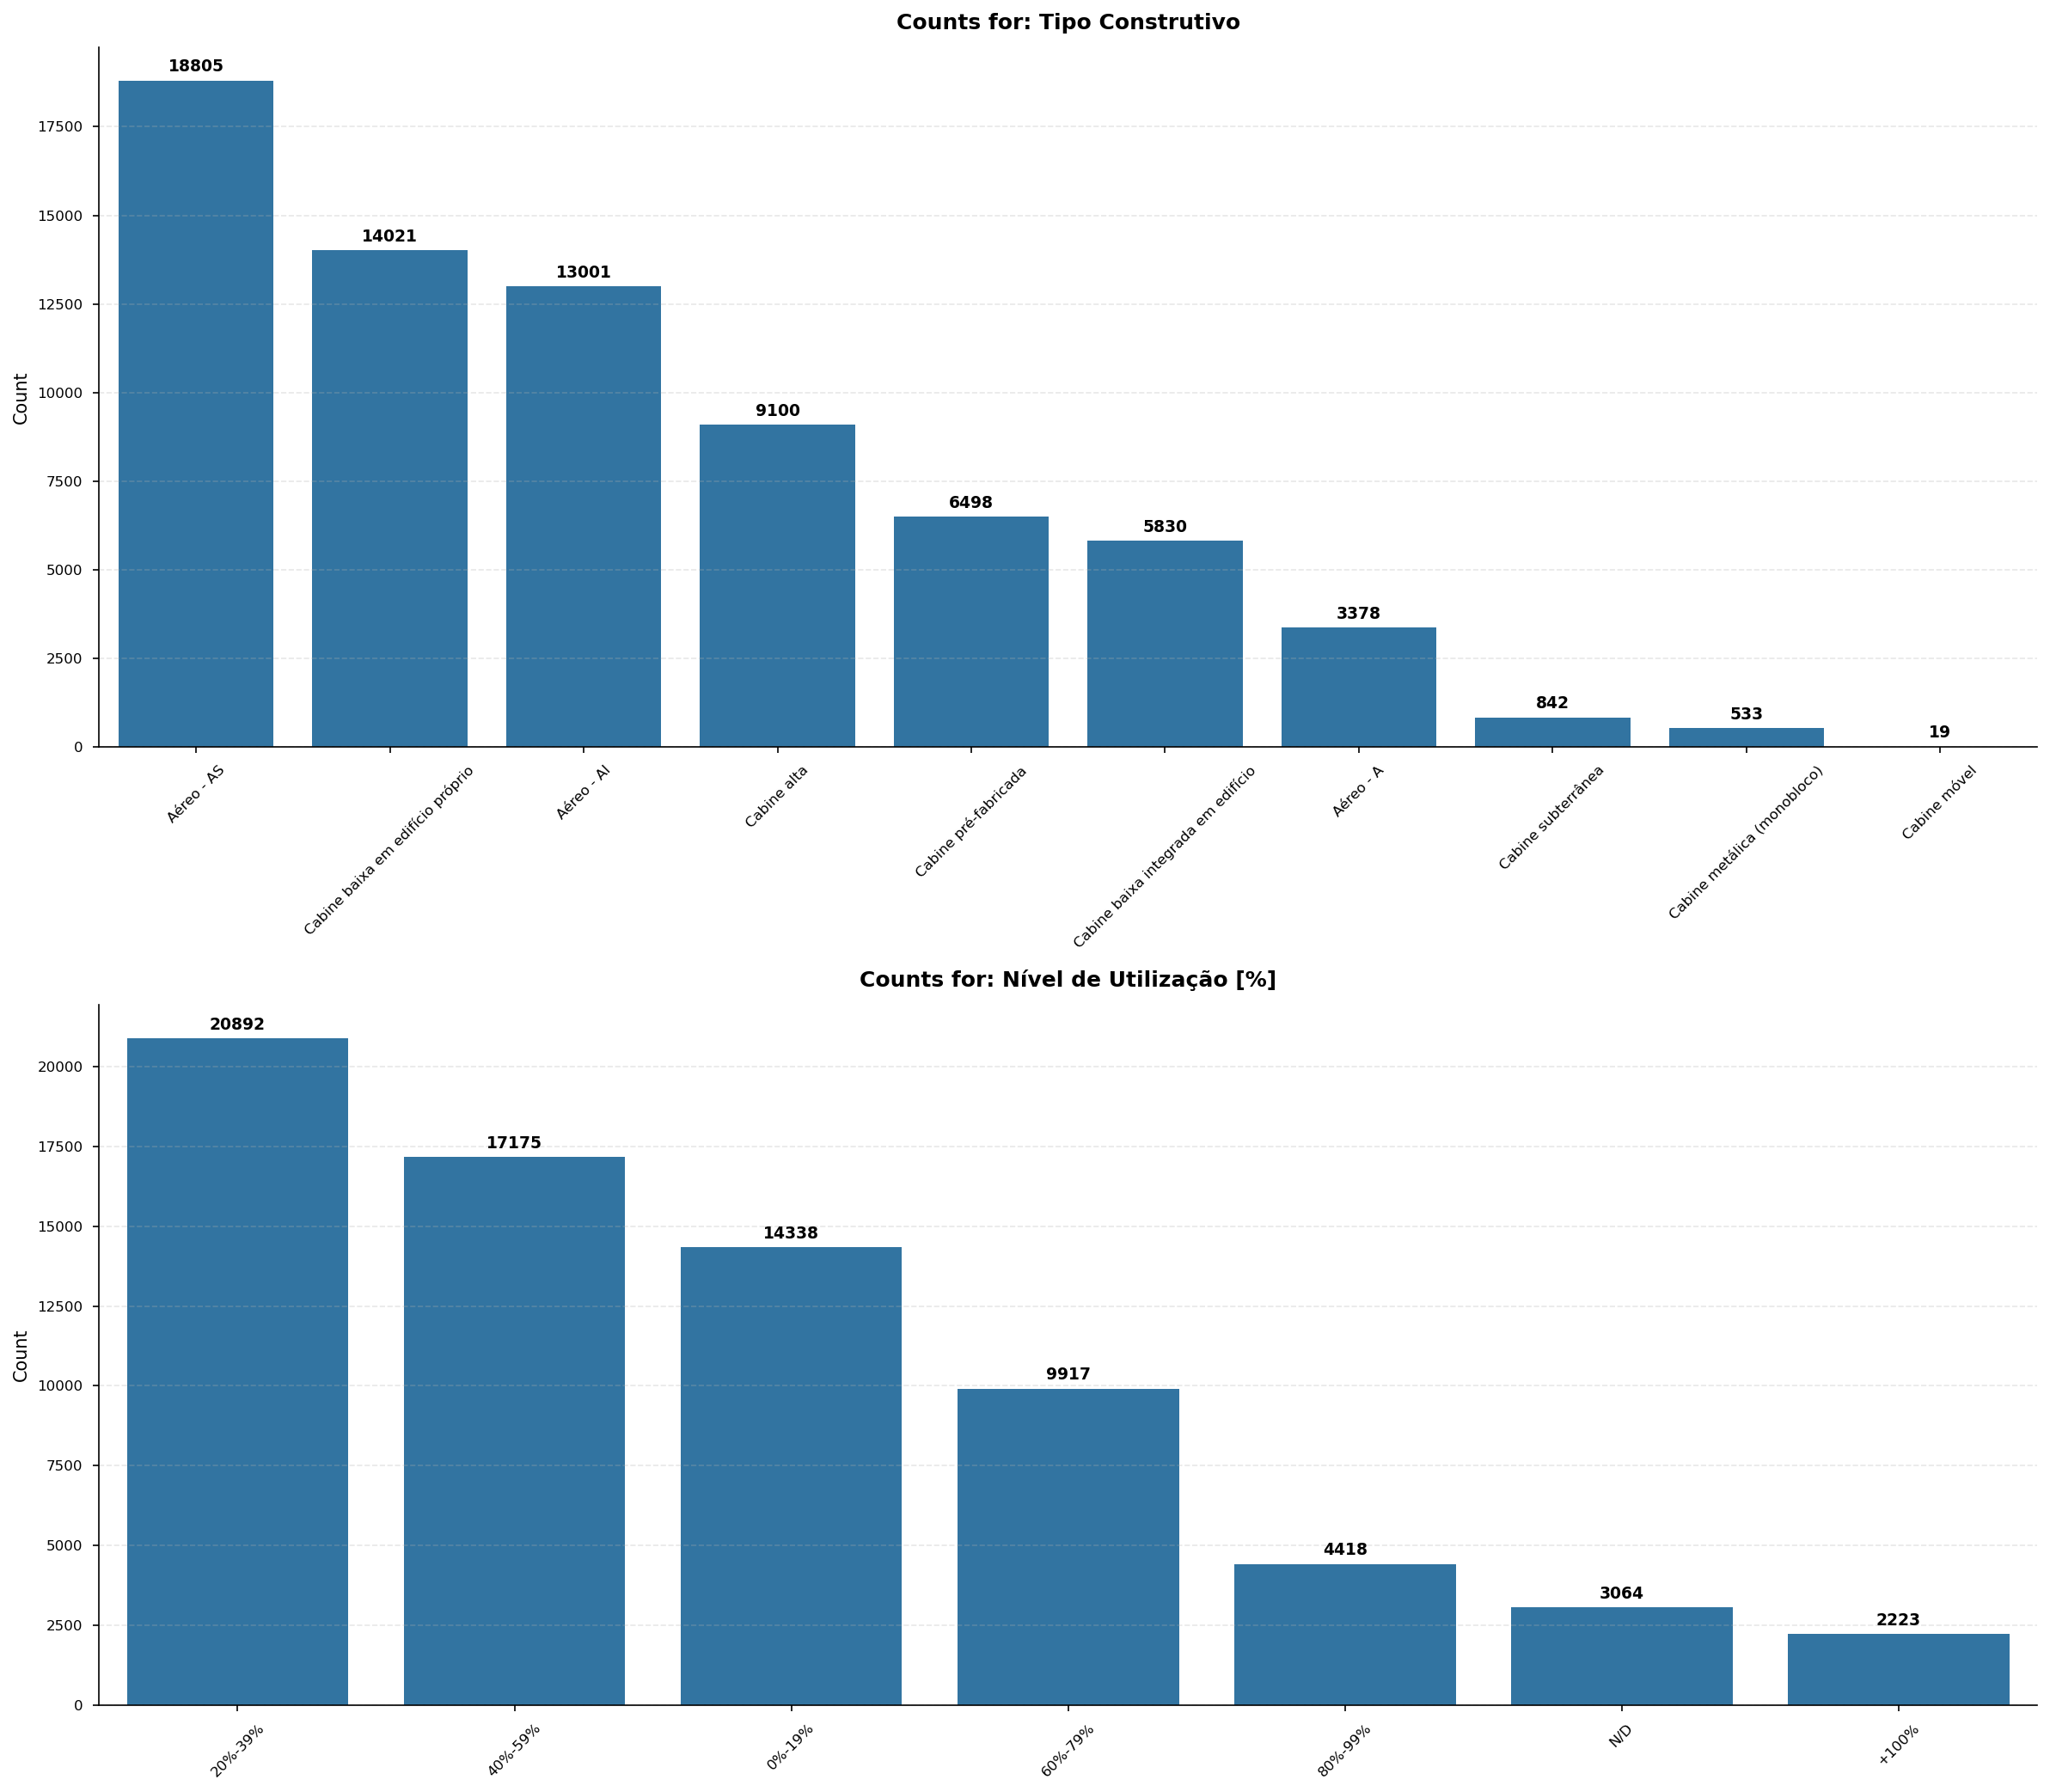

In [11]:
# 1. Filter out columns with > 20 unique values up front
categorical_columns = [
    col
    for col in df.select_dtypes(include=["object", "category"]).columns
    if df[col].nunique() <= 10
]

# 2. Dynamic grid layout calculation
num_cols = len(categorical_columns)
grid_cols = 1  # Adjust this to 3 or 4 if you have many columns
grid_rows = math.ceil(num_cols / grid_cols)

# 3. Create the single figure context
fig, axes = plt.subplots(
    grid_rows, grid_cols, figsize=(16, 14)
)
axes = axes.flatten()  # Flatten to easily loop over them with a single index

# 4. Populate the subplots
for i, column in enumerate(categorical_columns):
    ax = axes[i]

    # Create the sorted count plot on the specific subplot axis (ax=ax)
    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index,
        legend=False,
        ax=ax,
    )

    # Loop through all containers to label every single bar
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9, weight="bold")

    # Clean up labels per subplot
    ax.set_title(f"Counts for: {column}", fontsize=12, pad=10, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)


# 5. Hide any leftover/empty subplot boxes in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing and display
plt.tight_layout()
plt.show()

Como N/D é uma classe significativa é melhor considera-la para um modelo final.

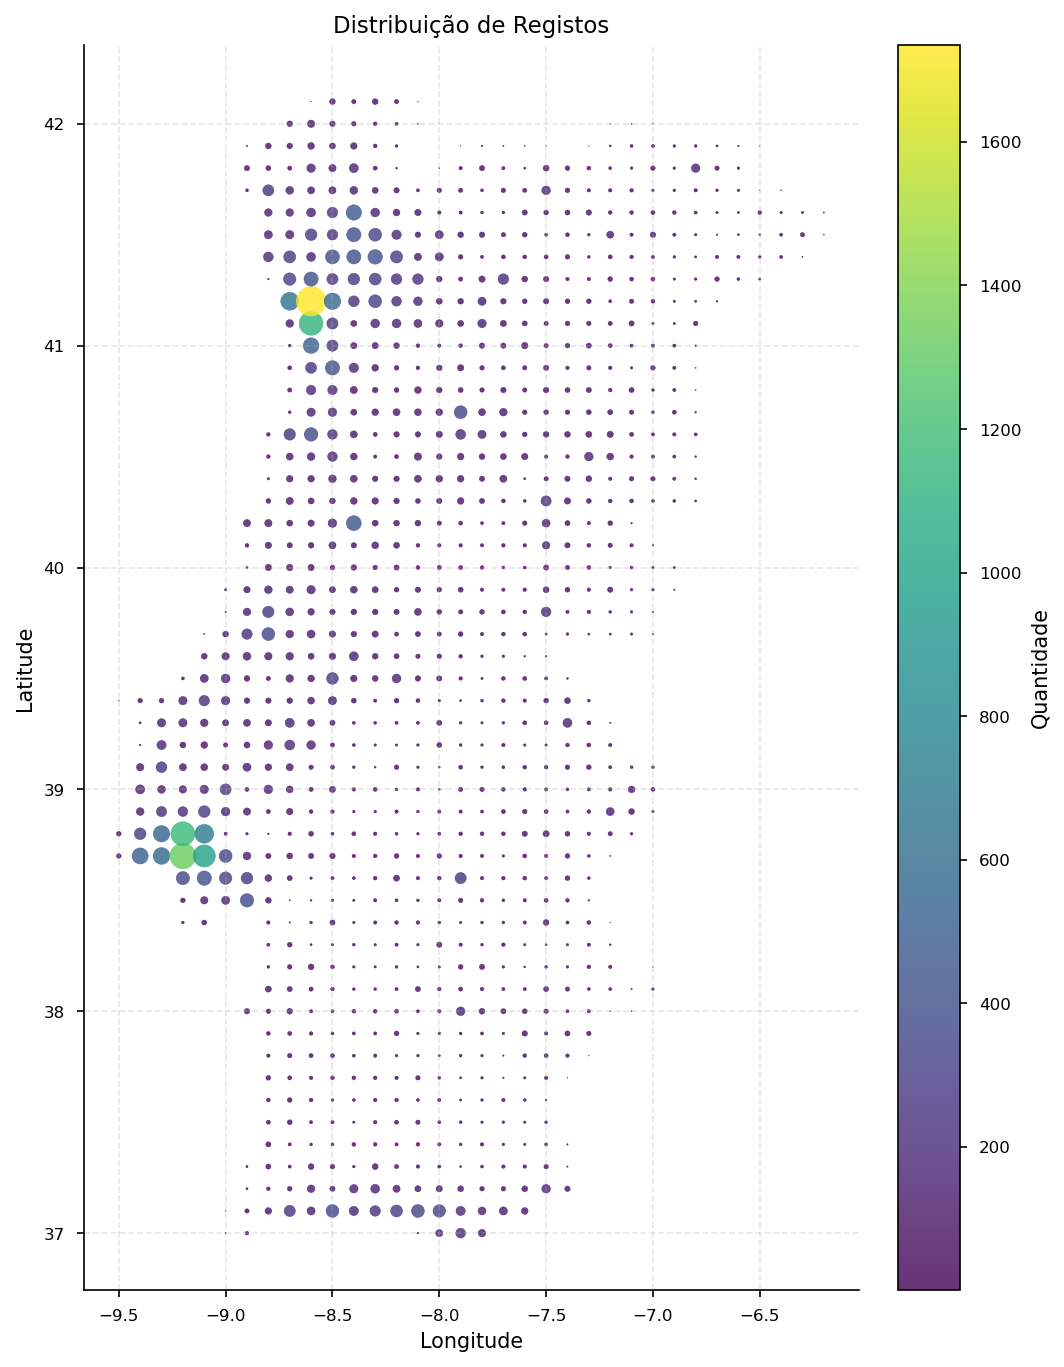

In [12]:
df_mapa = (
    df.assign(
        lat_round=df["latitude"].round(1),
        lon_round=df["longitude"].round(1)
    )
    .groupby(["lat_round", "lon_round"])
    .size()
    .reset_index(name="quantidade")
)

plt.figure(figsize=(7, 9))

# Plot standard points where color and size reflect "quantidade"
sc = plt.scatter(
    df_mapa["lon_round"], 
    df_mapa["lat_round"], 
    c=df_mapa["quantidade"], 
    cmap="viridis",
    s=df_mapa["quantidade"] / df_mapa["quantidade"].max() * 200, # Variable sizing
    alpha=0.8
)

plt.colorbar(sc, label="Quantidade")
plt.title("Distribuição de Registos")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

Ao olhar para este mapa de densidade, a primeira coisa que salta à vista é a forte concentração dos  dados ao longo de toda a faixa litoral de Portugal Continental.

Destacam-se claramente dois grandes "focos" a amarelo (onde há maior volume de registos): um na região da Grande Lisboa e outro na zona do Grande Porto.

Em contrapartida, nota-se perfeitamente que a zona interior do país está muito mais "vazia", com pontos de densidade muito mais baixos espalhados pelo território. No fundo, a distribuição no mapa acompanha, de forma muito clara, as zonas de maior e menor densidade populacional do país.

### Variáveis Numéricas


In [13]:
df.describe()

,Potência instalada [kVA],Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,PVE_PTD,D_PTD,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Util_Decimal,PFolga_PTD,latitude,longitude
count,72027.000000,72027.000000,50847.000000,72027.000000,1836.000000,72027.000000,72027.000000,72027.000000,72027.000000,72027.000000,72027.000000,72027.000000,72027.000000,7.202700e+04,68963.000000,72027.000000,72027.000000,72027.000000,68963.000000,72027.000000,50847.000000,1836.000000,72027.000000,68963.000000,68963.000000,72027.000000,72027.000000
mean,302.798825,302.798825,80941.484060,94.698002,6216.724401,20.203479,1381.490215,463.290614,0.280694,0.671746,21800.367904,21832.557235,484.294376,1.320000e+01,134.783315,2.506114,0.856743,0.556883,135.343310,5.752241,711.591520,36.666427,0.508043,0.513849,147.983315,39.865313,-8.361586
std,294.444527,294.444527,67146.029444,110.055146,2876.377899,2.017686,1723.710579,708.009567,0.240367,0.273099,17634.684356,17715.517084,431.611257,1.635503e-11,186.759871,1.083828,1.057501,0.687375,186.850323,8.513091,317.283001,26.495930,0.372627,0.246994,186.759871,1.358247,0.604654
min,0.000000,0.000000,5456.000000,20.000000,1622.000000,20.000000,23.218600,0.000000,0.000000,0.011698,589.000000,589.000000,19.000000,1.320000e+01,-13.200000,0.473284,0.000000,0.000000,-13.200000,0.000000,222.812500,3.222749,0.013908,0.190000,0.000000,36.974589,-9.505183
25%,100.000000,100.000000,34035.500000,20.000000,4271.750000,20.000000,382.569000,28.985000,0.064209,0.500703,8867.000000,8844.000000,194.000000,1.320000e+01,24.060000,1.817698,0.105130,0.068334,24.160309,1.923077,545.682423,20.220713,0.163934,0.390000,37.260000,38.767525,-8.751868
50%,250.000000,250.000000,60886.000000,54.000000,5574.500000,20.000000,842.179701,137.720000,0.229231,0.719614,17175.000000,17103.000000,377.000000,1.320000e+01,64.080000,2.298665,0.490339,0.318720,64.377532,2.906977,643.139785,29.957789,0.370370,0.390000,77.280000,39.969036,-8.467938
75%,400.000000,400.000000,106720.000000,124.000000,7393.500000,20.000000,1766.391301,625.790000,0.447381,0.911563,29747.000000,29771.000000,610.000000,1.320000e+01,211.280000,2.911925,1.172828,0.762338,211.348334,5.102041,770.474599,44.394482,1.000000,0.590000,224.480000,41.151804,-7.966075
max,8000.000000,8000.000000,804687.000000,1438.000000,22032.000000,106.000000,9065.655300,3494.920000,0.983568,1.000000,86026.000000,86712.000000,2278.000000,1.320000e+01,4476.400000,6.338273,5.395278,3.506931,4479.225328,283.500000,8820.000000,355.377778,1.000000,1.000000,4489.600000,42.149844,-6.214944


#### 1. Dimensão e Dados em Falta (Missing Values)

O dataset contém uma base de 72.027 registos analisados na maioria das colunas.
Há um grande número de nulos nas variáveis de geração de energia (Pot_Geracao_kW e Geracao_per_Cliente), que possuem apenas 1.836 registos. Isto indica que uma pequena minoria (~2.5%) dos postos/instalações tem registo de produção ativa (como painéis solares na área).
A coluna de Pot_Contratada_kVA também apresenta falhas, com apenas 50.847 registos válidos (cerca de 30% da base sem dados desta variável). Outras variáveis descritivas (como D_PTD, Util_Decimal) também têm cerca de 3.000 registos em falta.

#### 2. Assimetria (Outliers Severos / Right-Skewed)

Existe uma variabilidade extrema em variáveis-chave. Por exemplo:
N_Clientes: A mediana é 54, a média é 94, mas o máximo atinge valores absurdos de 1.438 clientes num só posto.
Potência instalada [kVA]: A maioria ronda os 250 kVA (mediana), mas há postos massivos com capacidades até 8.000 kVA. Isto sugere que há um pequeno grupo de PTDs (Postos de Transformação de Distribuição) altamente densos (zonas super urbanas/industriais) perante uma vasta maioria mais "leve" ou rural.

#### 3. Penetração LED vs Ineficiência

Adoção LED avançada: O LED_Ratio médio é de cerca de 67%, com a mediana em quase 72% e o percentil 75 já acima dos 91%. Isto demonstra que a atualização da rede de iluminação para LED não só já começou, como está fortemente instalada.
Margem para melhoria (Ineficiência): Apesar de bons níveis de LED, o Rate_Ineficiencia situa-se nos 28% (média), chegando os casos extremos perto dos 98%. Há, portanto, oportunidades claras de melhoria (por exemplo, ao reduzir P_IP_Inef).

#### 4. Capacidade e Utilização

A taxa de utilização média (Util_Decimal) está em torno de 51% (com metade a operar abaixo dos 39%).
Isto alinha-se perfeitamente com a variável PFolga_PTD (Folga real do PTD), indicando que, na generalidade, a rede de distribuição parece ter boas "gorduras" para evitar sobrecargas extremas.

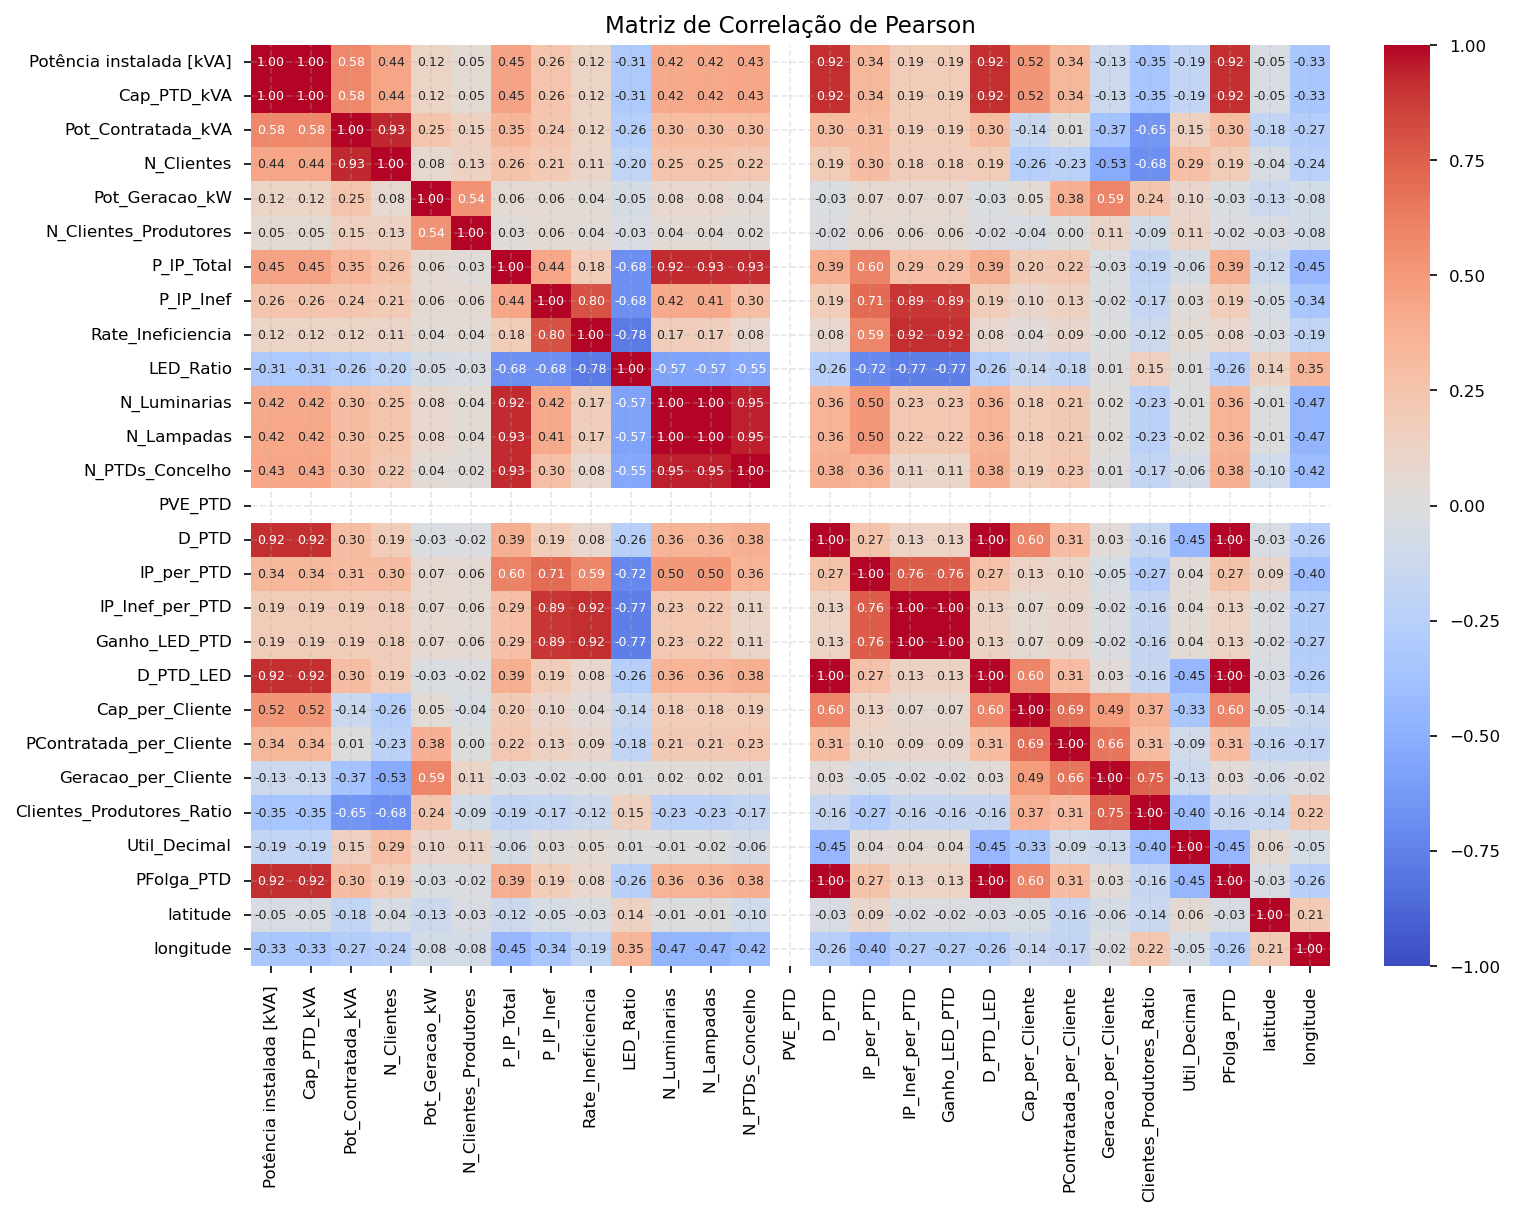

In [14]:
corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,
    annot_kws={"size": 6}, # Adjusted annotation size
    cmap='coolwarm',    
    fmt=".2f",           
    vmin=-1, vmax=1      
)

plt.title('Matriz de Correlação de Pearson')
plt.show()

/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_25778/2492322895.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar layout para não sobrepor o título


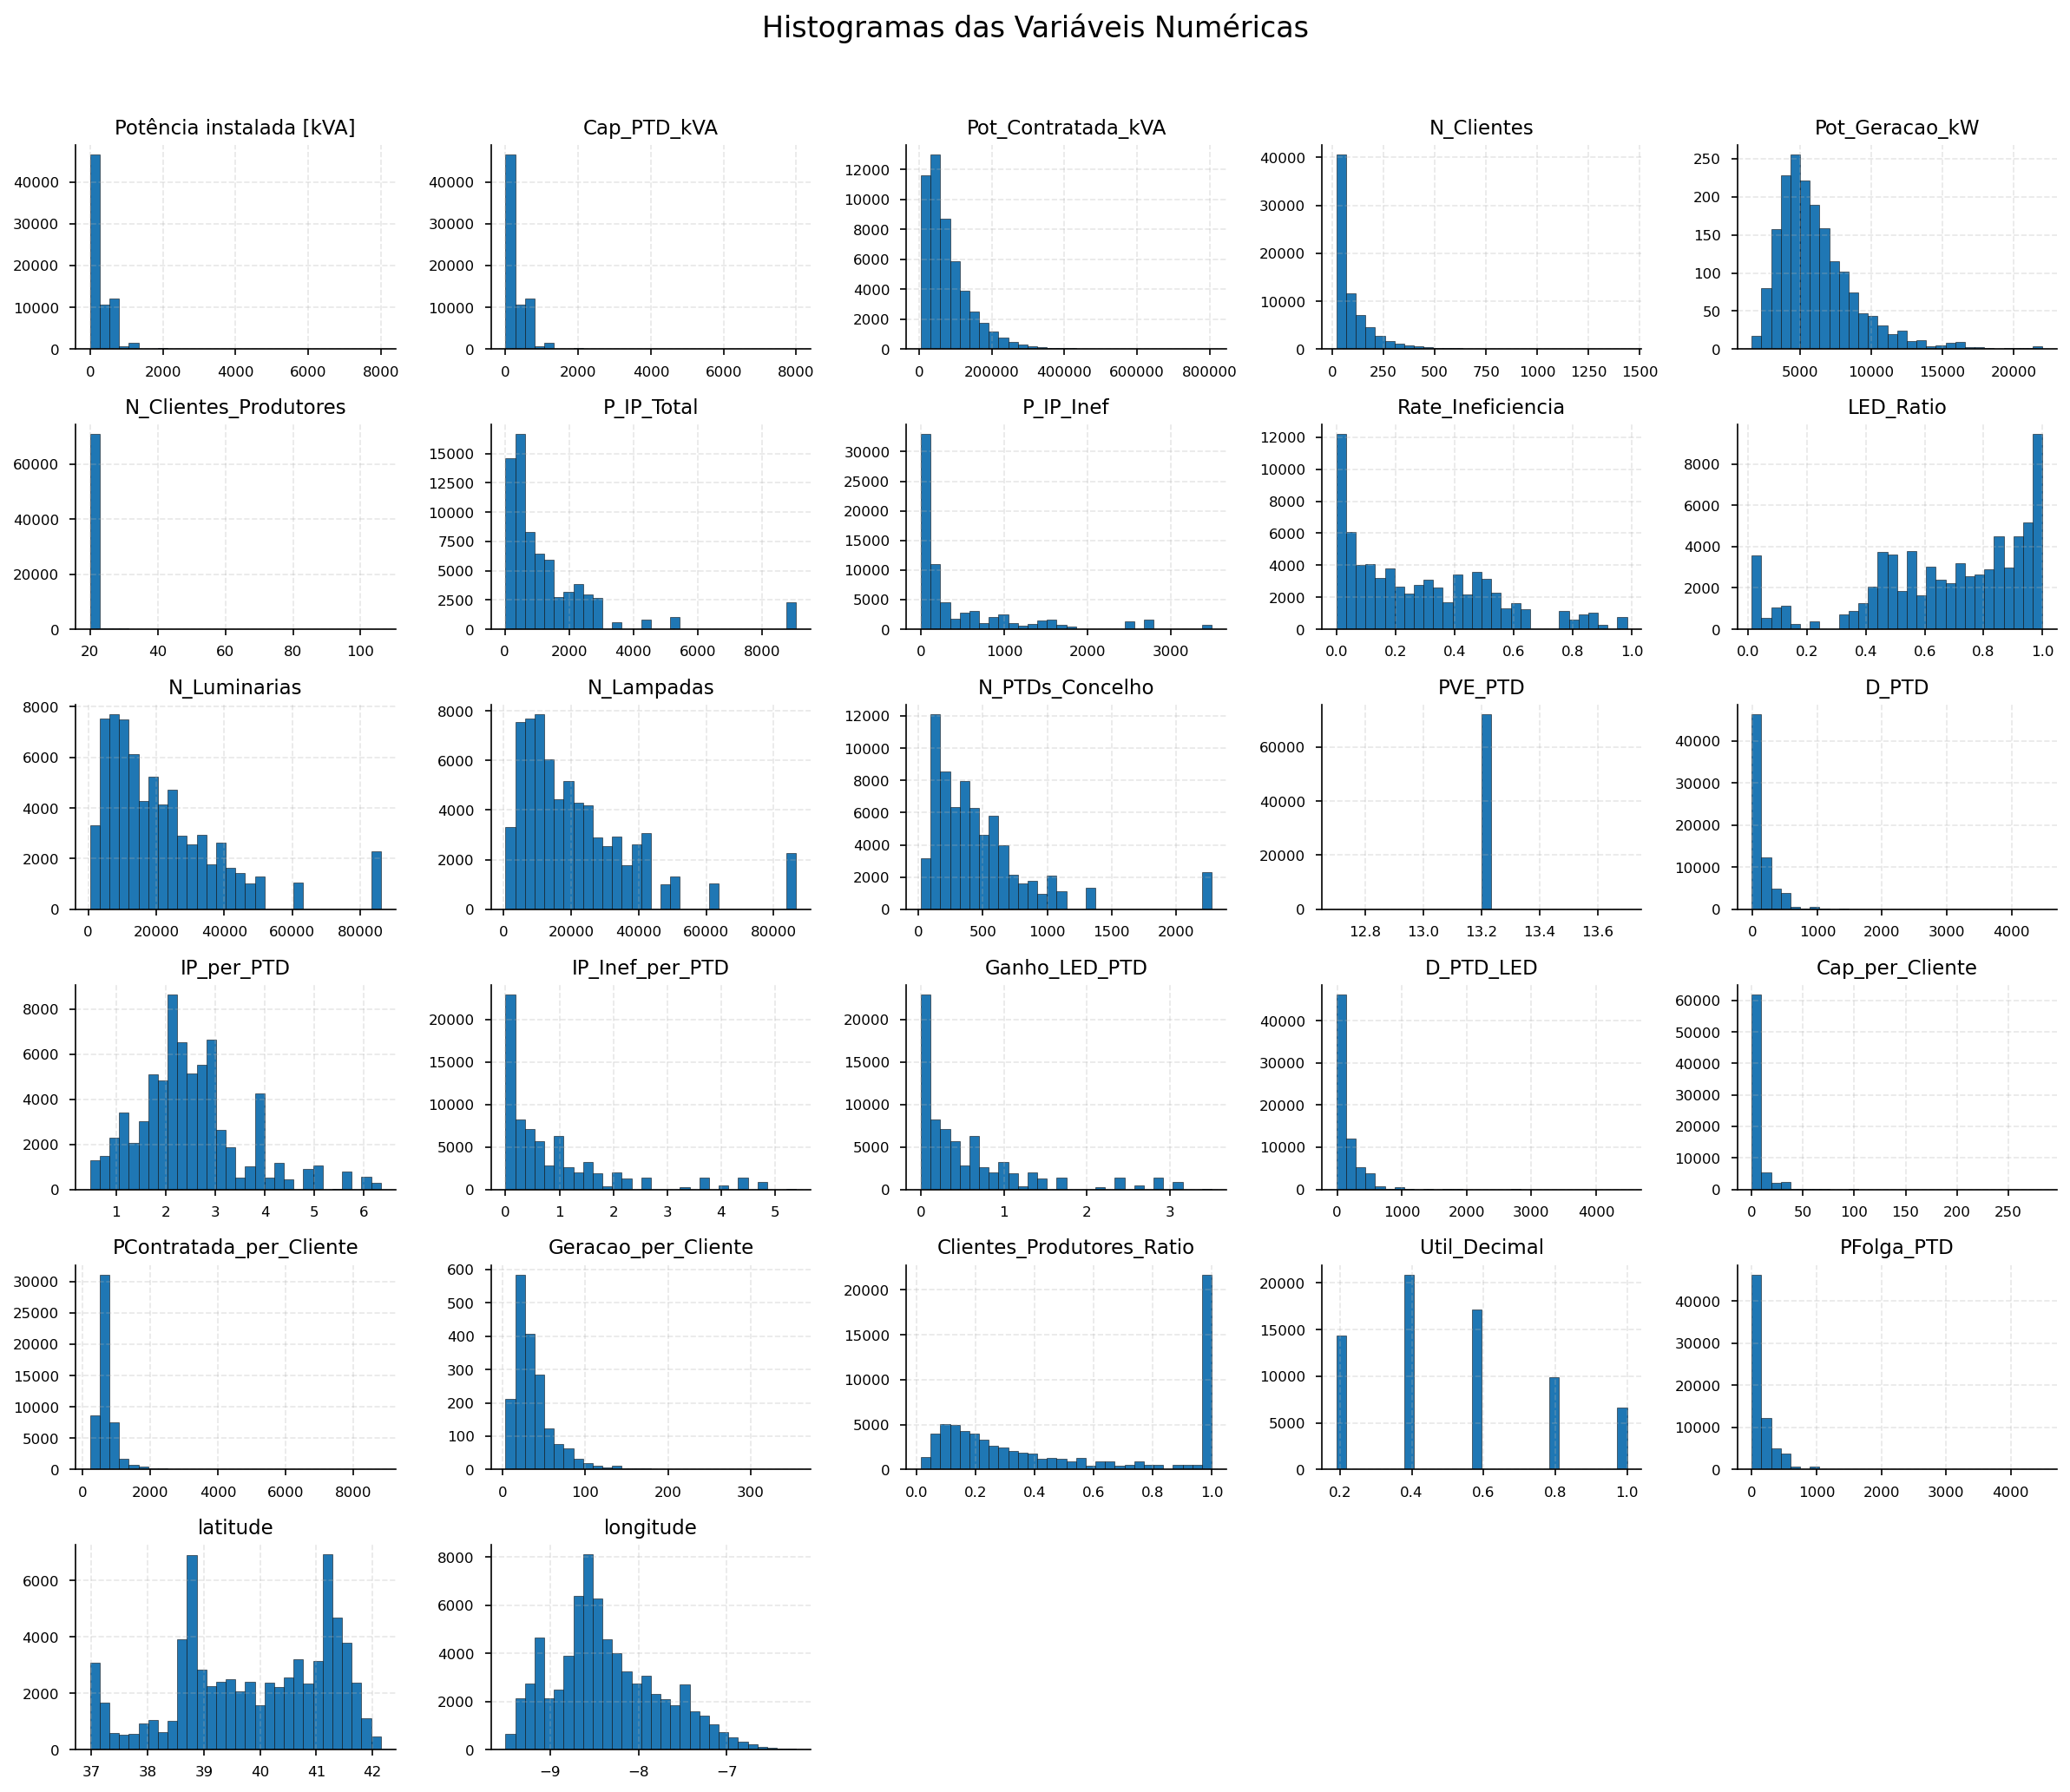

In [15]:
# Selecionar variáveis numéricas
numeric_df = df.select_dtypes(include=['number'])

# Criar histogramas para as variáveis numéricas
numeric_df.hist(figsize=(16, 14), bins=30, edgecolor='black')

plt.suptitle('Histogramas das Variáveis Numéricas', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar layout para não sobrepor o título
plt.show()

/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_25778/2018807543.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar layout para não sobrepor o título


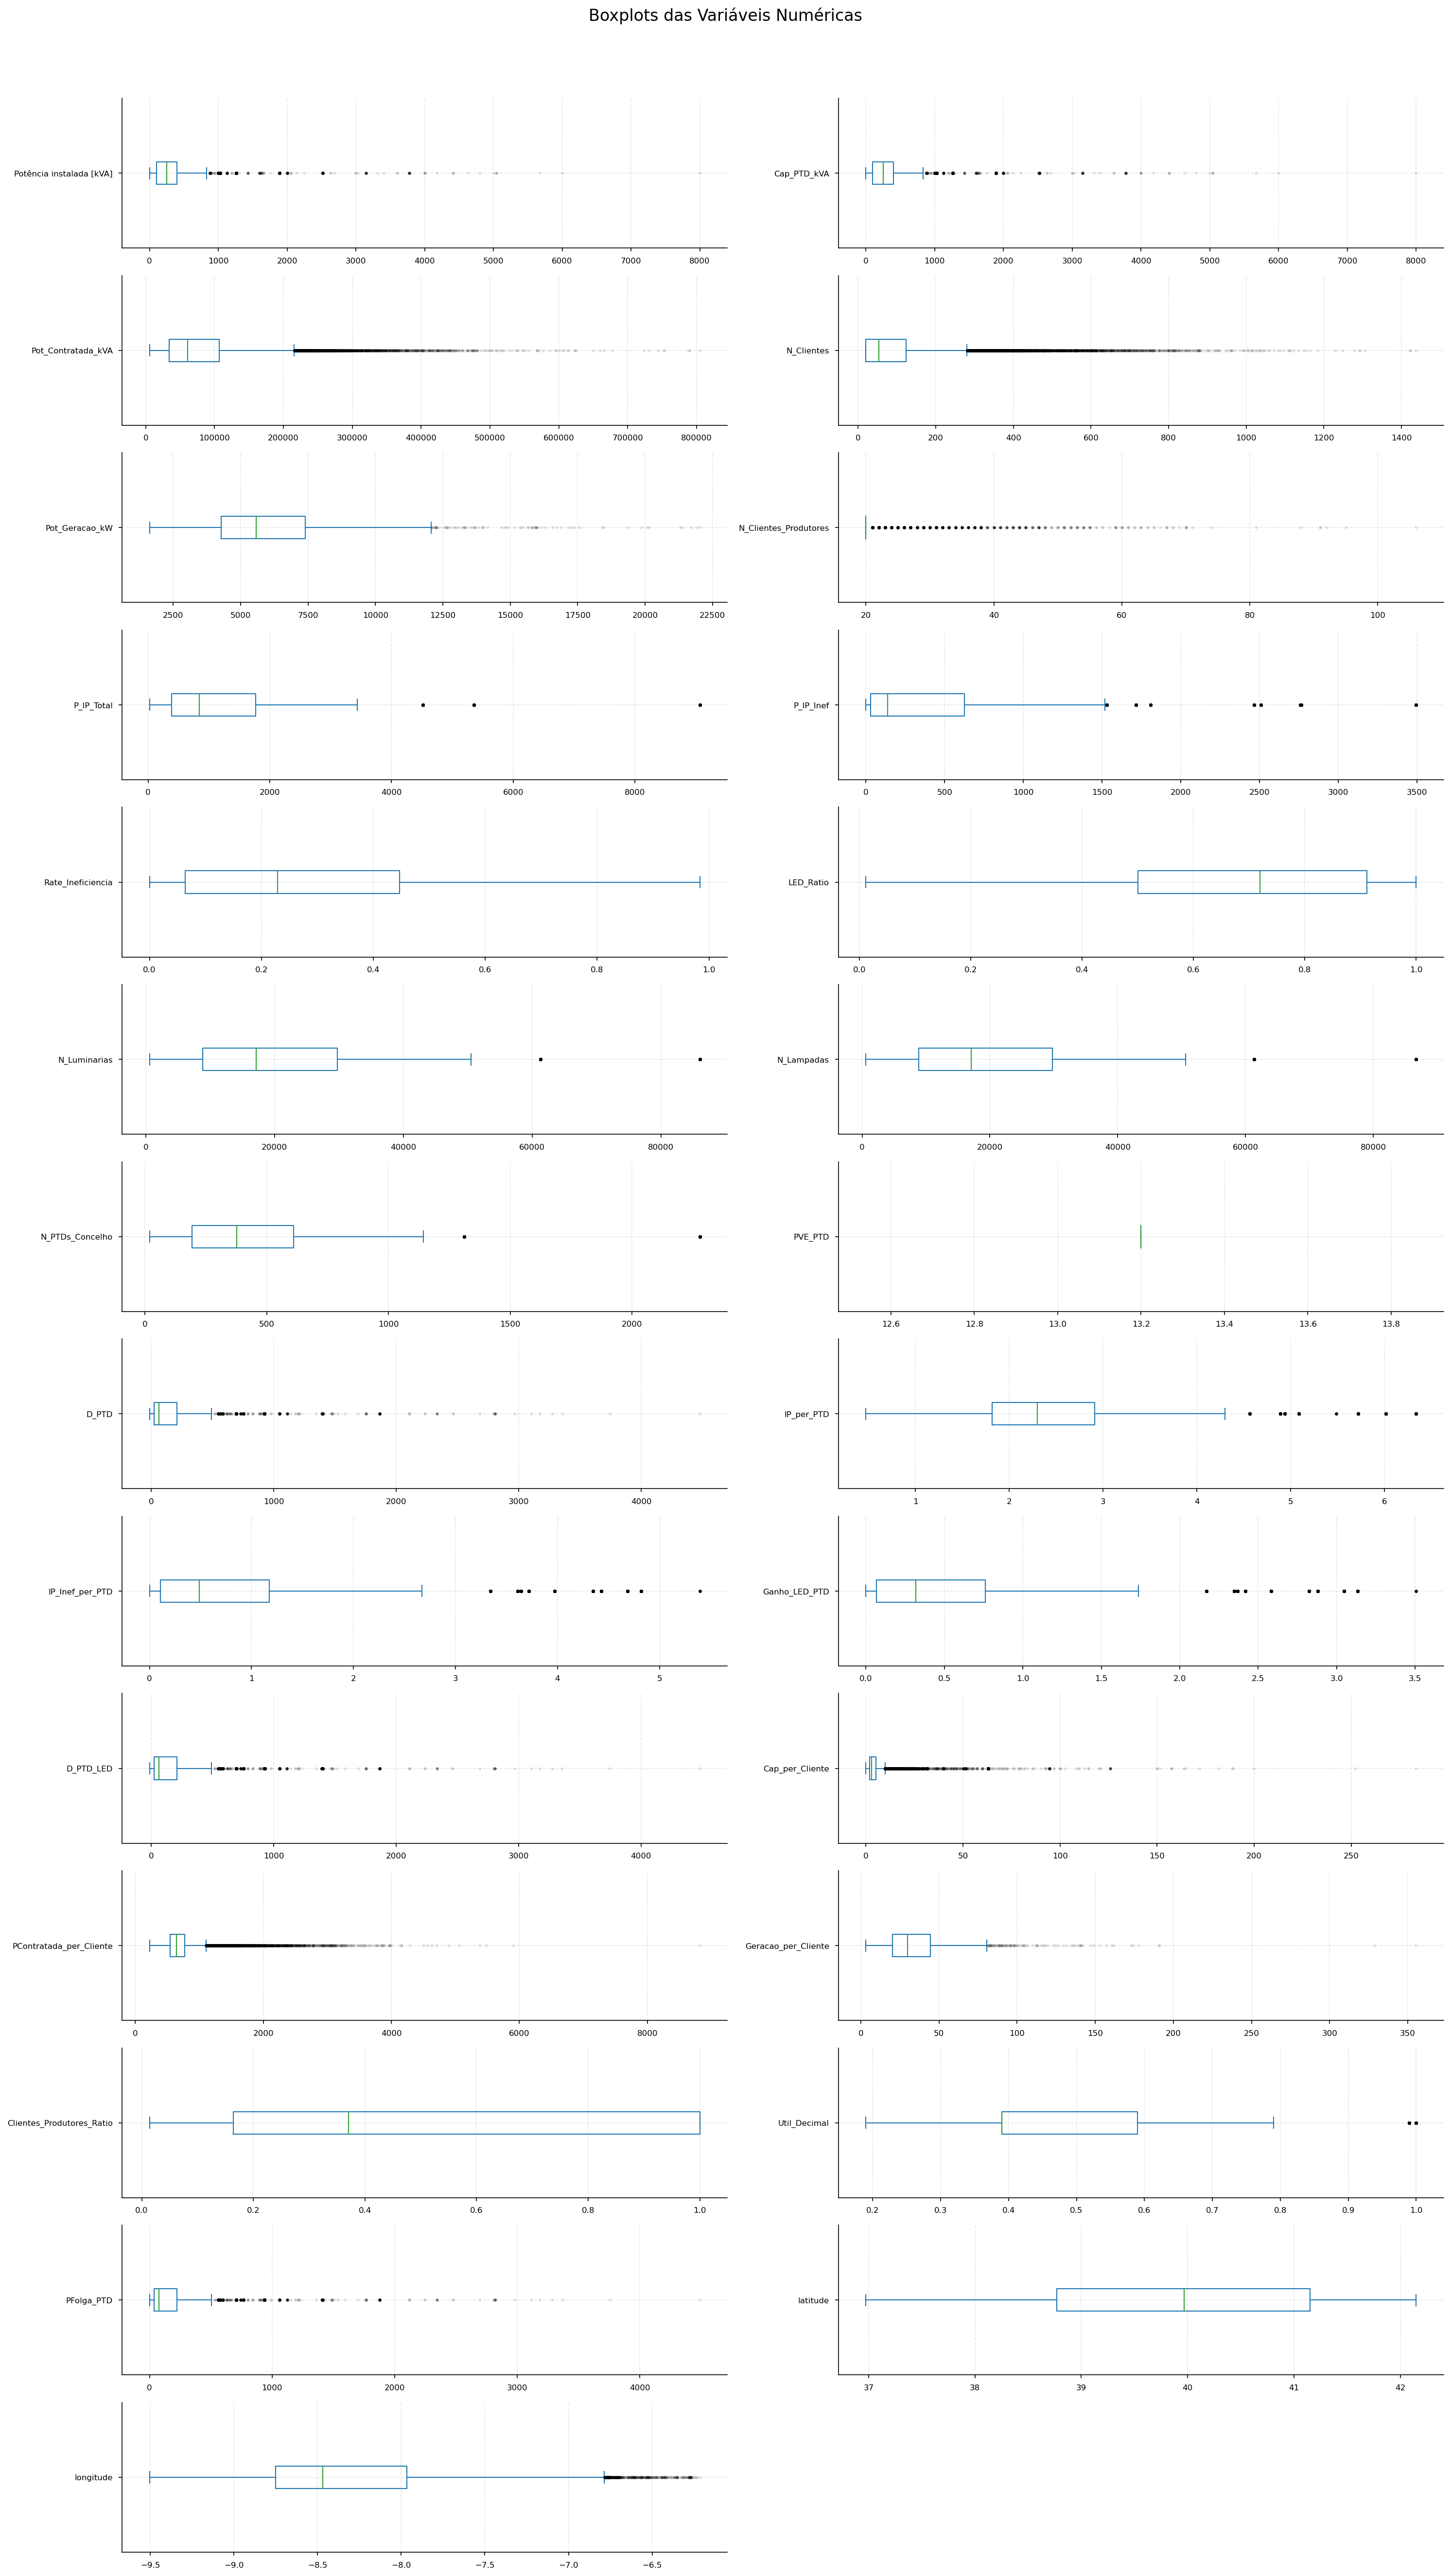

In [16]:
# Selecionar variáveis numéricas
numeric_df = df.select_dtypes(include=['number'])

num_cols = len(numeric_df.columns)
cols = 2
rows = math.ceil(num_cols / cols)

# Definir estilo dos outliers (fliers) com transparência e sem borda
# O parametro alpha=0.1 ajuda a visualizar onde há maior concentração de pontos
flierprops = dict(
    marker='o', 
    markerfacecolor='black', 
    markeredgecolor='none', 
    markersize=3, 
    alpha=0.1
)

# Criar boxplots em subplots separados
numeric_df.plot(
    kind='box', 
    subplots=True, 
    layout=(rows, cols), 
    figsize=(20, 36), 
    sharex=False, 
    sharey=False,
    fontsize=8,
    vert=False,
    flierprops=flierprops  # Aplicar a transparência aos outliers
)

plt.suptitle('Boxplots das Variáveis Numéricas', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar layout para não sobrepor o título
plt.show()

#### Tratamento de nulos

In [17]:
# 1. Imputação de Zeros para Variáveis de Geração
# O elevado número de nulos nestas colunas (~70k) reflete que a esmagadora maioria dos postos não tem produção injetada. 
# Preencher com 0 é a abordagem lógica.
df['Pot_Geracao_kW'] = df['Pot_Geracao_kW'].fillna(0)
df['Geracao_per_Cliente'] = df['Geracao_per_Cliente'].fillna(0)

# 2. Imputação pela Mediana (Potência Contratada)
# Faltam cerca de 21 mil registos (~30%). Sendo demasiados para eliminar, usamos a Mediana para não criar viés através da Média (que é desvirtuada por outliers mesmo após winsorization limitativo).
median_pot_contratada = df['Pot_Contratada_kVA'].median()
df['Pot_Contratada_kVA'] = df['Pot_Contratada_kVA'].fillna(median_pot_contratada)

median_pcont_per_cliente = df['PContratada_per_Cliente'].median()
df['PContratada_per_Cliente'] = df['PContratada_per_Cliente'].fillna(median_pcont_per_cliente)

# 3. Eliminação de Registos (Elimination / Dropping)
# As restantes variáveis - ['D_PTD', 'D_PTD_LED', 'Util_Decimal', 'PFolga_PTD'] - têm os exatos 3064 nulos em comum (aprox 4.2% dos dados).
# Como são indicadores-chave complexos de calcular que envolvem variáveis técnicas espaciais que provavelmente estão em falta na source, 
# a abordagem mais segura é eliminar as observações afetadas para assegurar a precisão do algoritmo.
cols_to_drop_na = ['D_PTD', 'D_PTD_LED', 'Util_Decimal', 'PFolga_PTD']
df.dropna(subset=cols_to_drop_na, inplace=True)

print(f"Dimensão final do dataset pós-limpeza de nulos: {df.shape}")
missing_info = df.isnull().sum()
print("\\nValores nulos restantes:")
if len(missing_info[missing_info > 0]) == 0:
    print("Nenhum! O dataset está totalmente preenchido.")
else:
    print(missing_info[missing_info > 0])


Dimensão final do dataset pós-limpeza de nulos: (68963, 33)
\nValores nulos restantes:
Nenhum! O dataset está totalmente preenchido.


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68963 entries, 0 to 72026
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Distrito                   68963 non-null  object  
 1   Concelho                   68963 non-null  object  
 2   CodDistritoConcelho        68963 non-null  category
 3   Código de Instalação       68963 non-null  object  
 4   Potência instalada [kVA]   68963 non-null  int64   
 5   Tipo Construtivo           68963 non-null  object  
 6   Cap_PTD_kVA                68963 non-null  int64   
 7   Pot_Contratada_kVA         68963 non-null  float64 
 8   N_Clientes                 68963 non-null  int64   
 9   Pot_Geracao_kW             68963 non-null  float64 
 10  N_Clientes_Produtores      68963 non-null  int64   
 11  P_IP_Total                 68963 non-null  float64 
 12  P_IP_Inef                  68963 non-null  float64 
 13  Rate_Ineficiencia          68963 non

#### Tratamento de outliers

In [19]:
# Variáveis que representam "volumes" / quantidades (fortemente enviesadas à direita em zonas urbanas)
# Para estas, o valor ser muito alto é real (e.g., um posto numa zona de alta densidade),
# logo vamos aplicar WINSORIZATION (limitar aos valores de Z-score limiar) para não perder a informação.
cols_to_winsorize = [
    'Potência instalada [kVA]', 'Cap_PTD_kVA', 'Pot_Contratada_kVA', 
    'N_Clientes', 'N_PTDs_Concelho', 'P_IP_Total', 'P_IP_Inef',
    'N_Luminarias', 'N_Lampadas', 'Cap_per_Cliente', 'PContratada_per_Cliente'
]

# Variáveis relacionadas a produção (muitos zeros, alguns outliers enormes)
# Winsorization é útil aqui para abafar instalações que parecem centrais inteiras
cols_prod = [
    'Pot_Geracao_kW', 'N_Clientes_Produtores', 'Geracao_per_Cliente'
]

# Variáveis que são Rácios, Índices ou Percentagens. 
# Valores extremos podem ser erros de cálculo na base de dados original.
# Nesses casos, a imputação (por exemplo com a mediana) pode ser mais segura se os identificarmos como outliers.
cols_to_impute = [
    'Rate_Ineficiencia', 'LED_Ratio', 'Util_Decimal', 'PFolga_PTD', 
    'Clientes_Produtores_Ratio', 'IP_per_PTD', 'IP_Inef_per_PTD', 
    'Ganho_LED_PTD', 'D_PTD', 'D_PTD_LED', 'PVE_PTD'
]

z_thresh = 3

print("--- WINSORIZATION ---")
for col in cols_to_winsorize + cols_prod:
    if col not in df.columns: continue
    
    mean_val = df[col].mean()
    std_val = df[col].std()
    
    lower_bound = mean_val - z_thresh * std_val
    upper_bound = mean_val + z_thresh * std_val
    
    # As quantidades devem ser positivas
    if lower_bound < 0:
        lower_bound = 0
        
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_count = outliers_mask.sum()
    
    if outliers_count > 0:
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
        print(f"[{col}] {outliers_count} outliers winsorizados.")
        
print("\n\n--- IMPUTATION (SUBSTITUIR POR MEDIANA) ---")
for col in cols_to_impute:
    if col not in df.columns: continue
    
    mean_val = df[col].mean()
    std_val = df[col].std()
    
    lower_bound = mean_val - z_thresh * std_val
    upper_bound = mean_val + z_thresh * std_val
    
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outliers_count = outliers_mask.sum()
    
    if outliers_count > 0:
        median_val = df[col].median()
        # Imputar outliers com a mediana
        df.loc[outliers_mask, col] = median_val
        print(f"[{col}] {outliers_count} outliers imputados com a mediana ({median_val:.3f}).")
        
# Verificar se existem variáveis com valores muito absurdos fisicamente que precisemos remover (Trimming)
# ex: valores negativos de distâncias, ou taxas de utilização negativas
# Para taxas e ratios, elas deveriam estar entre 0 e 1 (ou 100%).
invalid_mask = pd.Series(False, index=df.index)

--- WINSORIZATION ---
[Potência instalada [kVA]] 1666 outliers winsorizados.
[Cap_PTD_kVA] 1666 outliers winsorizados.
[Pot_Contratada_kVA] 1421 outliers winsorizados.
[N_Clientes] 1405 outliers winsorizados.
[N_PTDs_Concelho] 2180 outliers winsorizados.
[P_IP_Total] 2180 outliers winsorizados.
[P_IP_Inef] 2310 outliers winsorizados.
[N_Luminarias] 2180 outliers winsorizados.
[N_Lampadas] 2180 outliers winsorizados.
[Cap_per_Cliente] 2382 outliers winsorizados.
[PContratada_per_Cliente] 1355 outliers winsorizados.
[Pot_Geracao_kW] 1619 outliers winsorizados.
[N_Clientes_Produtores] 721 outliers winsorizados.
[Geracao_per_Cliente] 1211 outliers winsorizados.


--- IMPUTATION (SUBSTITUIR POR MEDIANA) ---
[PFolga_PTD] 981 outliers imputados com a mediana (77.280).
[IP_per_PTD] 819 outliers imputados com a mediana (2.299).
[IP_Inef_per_PTD] 2200 outliers imputados com a mediana (0.490).
[Ganho_LED_PTD] 2200 outliers imputados com a mediana (0.319).
[D_PTD] 981 outliers imputados com a medi

#### Testes de Independencia ANOVA (PFolga_PTD)

In [20]:
target_var = 'PFolga_PTD'
alpha = 0.05

print(f"--- ANÁLISE DE INDEPENDÊNCIA COM A TARGET: {target_var} ---\n")

# Para armazenar resultados
results = []
vars_to_keep = []

# Separar numéricas (correlação de Pearson/Spearman) e categóricas (ANOVA/Kruskal)
num_cols_test = df.select_dtypes(include=['number']).columns.drop(target_var)
cat_cols_test = df.select_dtypes(include=['object', 'category']).columns

# 1. TESTE PARA VARIÁVEIS NUMÉRICAS (Correlação de Spearman - mais robuso que Pearson)
for col in num_cols_test:
    # Retirar nulos (se houver algum extra) para o teste
    valid_data = df[[col, target_var]].dropna()
    
    if len(valid_data) > 1:
        corr, p_value = stats.spearmanr(valid_data[col], valid_data[target_var])
        keep = 'Yes' if p_value < alpha else 'No'
        if keep == 'Yes': vars_to_keep.append(col)
            
        results.append({
            'Variável': col,
            'Tipo': 'Numérica',
            'Teste': 'Spearman Correlation',
            'Estatística (Corr/F)': corr,
            'P-Value': p_value,
            'Manter (p < 0.05)': keep
        })

# 2. TESTES PARA VARIÁVEIS CATEGÓRICAS (ANOVA)
for col in cat_cols_test:
    valid_data = df[[col, target_var]].dropna()
    groups = [group[target_var].values for name, group in valid_data.groupby(col)]
    
    # Executar ANOVA apenas se tivermos mais que um grupo e dados suficientes
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
        keep = 'Yes' if p_value < alpha else 'No'
        if keep == 'Yes': vars_to_keep.append(col)
            
        results.append({
            'Variável': col,
            'Tipo': 'Categórica',
            'Teste': 'ANOVA (F-oneway)',
            'Estatística (Corr/F)': f_stat,
            'P-Value': p_value,
            'Manter (p < 0.05)': keep
        })

# 3. EXIBIR TABELA
results_df = pd.DataFrame(results)

# Formatar para exibição limpa
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.5f}')
print(results_df.sort_values(by='P-Value').to_string(index=False))

print("\n--- CONCLUSÃO ---")
print(f"Número total de variáveis testadas: {len(results_df)}")
print(f"Número de variáveis sugeridas a MANTER (associadas à target): {len(vars_to_keep)}")
print(f"Variáveis a DESCARTAR (Independentes da target, p >= 0.05): \n{results_df[results_df['Manter (p < 0.05)'] == 'No']['Variável'].tolist()}")

--- ANÁLISE DE INDEPENDÊNCIA COM A TARGET: PFolga_PTD ---



/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_25778/3860725695.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.spearmanr(valid_data[col], valid_data[target_var])
/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_25778/3860725695.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[target_var].values for name, group in valid_data.groupby(col)]


                 Variável       Tipo                Teste  Estatística (Corr/F)  P-Value Manter (p < 0.05)
 Potência instalada [kVA]   Numérica Spearman Correlation               0.81471  0.00000               Yes
      CodDistritoConcelho Categórica     ANOVA (F-oneway)              74.50563  0.00000               Yes
                 Concelho Categórica     ANOVA (F-oneway)              74.50563  0.00000               Yes
                 Distrito Categórica     ANOVA (F-oneway)             566.54451  0.00000               Yes
                longitude   Numérica Spearman Correlation              -0.29203  0.00000               Yes
             Util_Decimal   Numérica Spearman Correlation              -0.53893  0.00000               Yes
Clientes_Produtores_Ratio   Numérica Spearman Correlation              -0.23758  0.00000               Yes
  PContratada_per_Cliente   Numérica Spearman Correlation               0.17248  0.00000               Yes
          Cap_per_Cliente   Numérica 

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:573: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/var/folders/3_/w7q31t691ks090f2jpvlnn580000gn/T/ipykernel_25778/3860725695.py:40: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*groups)


In [23]:
# Definir o limiar de correlação e a variável alvo
threshold = 0.95
target_var = 'PFolga_PTD'

print("--- REMOÇÃO DE VARIÁVEIS ALTAMENTE CORRELACIONADAS ---")

# Selecionar apenas as variáveis numéricas
num_df = df.select_dtypes(include=['number'])

# Calcular a matriz de correlação absoluta
corr_matrix = num_df.corr().abs()

# Obter as variáveis no triângulo superior da matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Encontrar variáveis com correlação superior ao limiar
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# Certificar que a variável alvo não é removida
if target_var in to_drop:
    to_drop.remove(target_var)
    
print(f"Variáveis a remover por correlação ({threshold}): {to_drop}\\n")

# Analisar quais pares motivaram a remoção
for col in to_drop:
    high_corr_with = upper.index[upper[col] > threshold].tolist()
    print(f"- '{col}' será removida pois tem alta correlação com: {high_corr_with}")

# Remover as variáveis selecionadas do DataFrame original
df = df.drop(columns=to_drop)

print(f"\nDimensão do dataset após remoção: {df.shape}")

--- REMOÇÃO DE VARIÁVEIS ALTAMENTE CORRELACIONADAS ---
Variáveis a remover por correlação (0.95): ['Cap_PTD_kVA', 'N_Lampadas', 'Ganho_LED_PTD', 'D_PTD_LED', 'Geracao_per_Cliente']\n
- 'Cap_PTD_kVA' será removida pois tem alta correlação com: ['Potência instalada [kVA]']
- 'N_Lampadas' será removida pois tem alta correlação com: ['N_Luminarias']
- 'Ganho_LED_PTD' será removida pois tem alta correlação com: ['IP_Inef_per_PTD']
- 'D_PTD_LED' será removida pois tem alta correlação com: ['D_PTD']
- 'Geracao_per_Cliente' será removida pois tem alta correlação com: ['Pot_Geracao_kW']

Dimensão do dataset após remoção: (68963, 28)
